In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [6]:
df.info()

NameError: name 'df' is not defined

# Data Load

In [7]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\Mini Project\Predict Customer Personality to Boost Marketing Campaign by Using Machine Learning\tahap02\marketing_campaign_data.csv")
df

,Unnamed: 0,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,5524,1957,S1,Lajang,58138000.0,0,0,04-09-2012,58,...,7,0,0,0,0,0,0,3,11,1
1,1,2174,1954,S1,Lajang,46344000.0,1,1,08-03-2014,38,...,5,0,0,0,0,0,0,3,11,0
2,2,4141,1965,S1,Bertunangan,71613000.0,0,0,21-08-2013,26,...,4,0,0,0,0,0,0,3,11,0
3,3,6182,1984,S1,Bertunangan,26646000.0,1,0,10-02-2014,26,...,6,0,0,0,0,0,0,3,11,0
4,4,5324,1981,S3,Menikah,58293000.0,1,0,19-01-2014,94,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,2235,10870,1967,S1,Menikah,61223000.0,0,1,13-06-2013,46,...,5,0,0,0,0,0,0,3,11,0
2236,2236,4001,1946,S3,Bertunangan,64014000.0,2,1,10-06-2014,56,...,7,0,0,0,1,0,0,3,11,0
2237,2237,7270,1981,S1,Cerai,56981000.0,0,0,25-01-2014,91,...,6,0,1,0,0,0,0,3,11,0
2238,2238,8235,1956,S2,Bertunangan,69245000.0,0,1,24-01-2014,8,...,3,0,0,0,0,0,0,3,11,0


# Overall Conversion Rate

In [8]:
conversion_rate = df["Response"].mean()

print(f"Conversion Rate: {conversion_rate:.2%}")

Conversion Rate: 14.91%


# Pembentukan Grup Umur

In [9]:
current_year = 2020

df["Age"] = current_year - df["Year_Birth"]

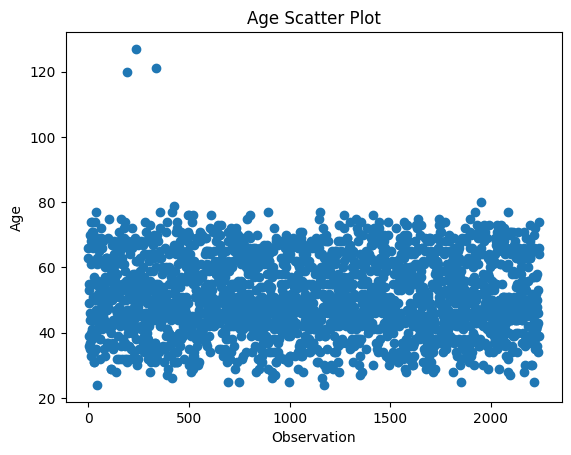

In [10]:
plt.scatter(df.index, df["Age"])

plt.title("Age Scatter Plot")
plt.xlabel("Observation")
plt.ylabel("Age")
plt.show()

In [11]:
df = df[df['Age'] <= 90]

In [12]:
df["Age"].describe()

count    2237.000000
mean       51.098346
std        11.701917
min        24.000000
25%        43.000000
50%        50.000000
75%        61.000000
max        80.000000
Name: Age, dtype: float64

In [13]:
# grouping Age

bins = [0, 18, 25, 35, 45, np.inf]
labels = ["young", "teen", "young_adult", "adult", "senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

In [14]:
df[["Year_Birth","Age","Age_Group"]].head()

,Year_Birth,Age,Age_Group
0,1957,63,senior
1,1954,66,senior
2,1965,55,senior
3,1984,36,adult
4,1981,39,adult


In [15]:
df["Age_Group"].value_counts()

Age_Group
senior         1542
adult           506
young_adult     187
teen              2
young             0
Name: count, dtype: int64

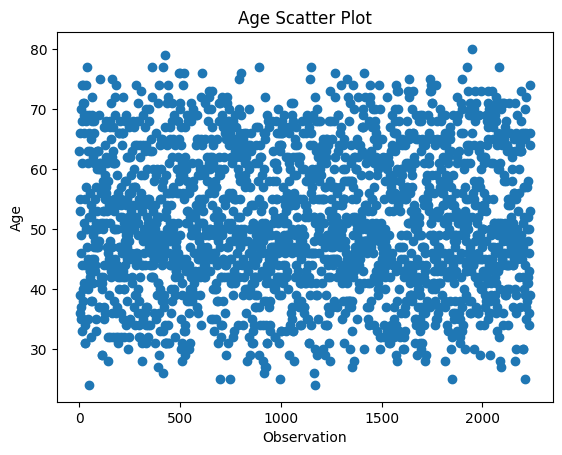

In [16]:
plt.scatter(df.index, df["Age"])

plt.title("Age Scatter Plot")
plt.xlabel("Observation")
plt.ylabel("Age")
plt.show()

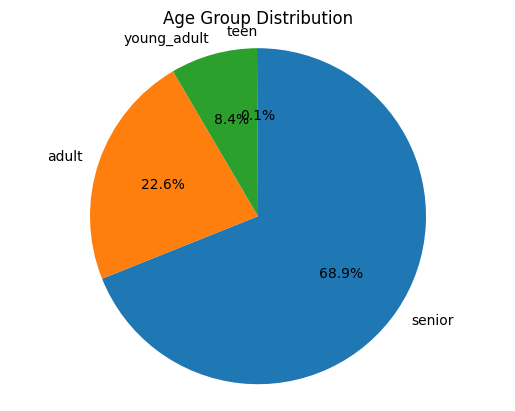

In [17]:
group_counts = df["Age_Group"].value_counts()

# 4. Filter out groups with 0 data AND sort by descending order
group_counts = group_counts[group_counts > 0].sort_values(ascending=False)

# 5. Plot the pie chart
plt.pie(
    group_counts, 
    labels=group_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    counterclock=False
)

plt.title("Age Group Distribution")
plt.axis('equal')
plt.show()

# Plot Relationship Between Conversion Rate and User Type

In [18]:
conversion_by_age = (
    df.groupby("Age_Group")["Response"]
      .mean()
      .reset_index()
)

print(conversion_by_age)

     Age_Group  Response
0         teen  0.500000
1  young_adult  0.165775
2        adult  0.152174
3       senior  0.145914


In [19]:
conversion_by_age = (
    df.groupby("Age_Group")["Response"]
      .mean()
      .reset_index()
)

# Convert to percentage numbers (e.g., 15.20)
conversion_by_age["Response"] = (conversion_by_age["Response"] * 100).round(2)

print(conversion_by_age)

     Age_Group  Response
0         teen     50.00
1  young_adult     16.58
2        adult     15.22
3       senior     14.59


C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_18336\1894312892.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


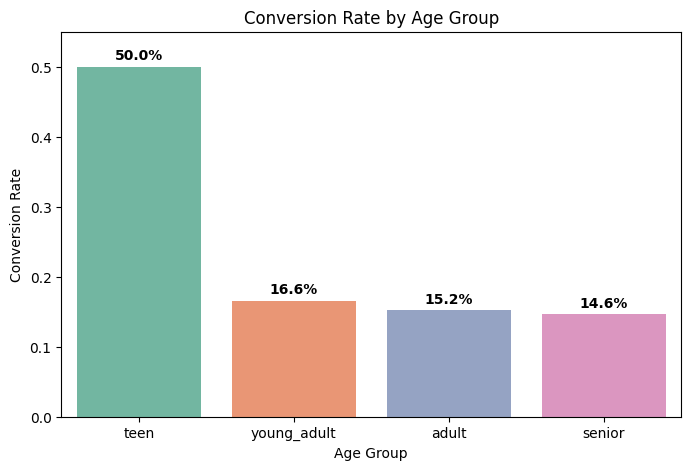

In [12]:
plt.figure(figsize=(8,5))

order = (
    conversion_by_age
    .sort_values("Response", ascending=False)["Age_Group"]
)

ax = sns.barplot(
    data=conversion_by_age,
    x="Age_Group",
    y="Response",
    order=order,
    palette="Set2"
)

#pemberian label pada ujung bar
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1%}",  # untuk format persentase
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),    
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate")
plt.ylim(0, conversion_by_age["Response"].max() + 0.05)

plt.show()

In [13]:
##p < 0.05 → Adanya pengaruh umur pada respon kampanye.
##p ≥ 0.05 → Tidak ada pengaruh.

from scipy.stats import chi2_contingency

table = pd.crosstab(df["Age_Group"], df["Response"])

chi2, p, dof, expected = chi2_contingency(table)

print(f"P-value: {p:.2f}")


P-value: 0.47


# Cleaning Data

## Quick check

In [14]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 2237 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Unnamed: 0           2237 non-null   int64   
 1   ID                   2237 non-null   int64   
 2   Year_Birth           2237 non-null   int64   
 3   Education            2237 non-null   str     
 4   Marital_Status       2237 non-null   str     
 5   Income               2213 non-null   float64 
 6   Kidhome              2237 non-null   int64   
 7   Teenhome             2237 non-null   int64   
 8   Dt_Customer          2237 non-null   str     
 9   Recency              2237 non-null   int64   
 10  MntCoke              2237 non-null   int64   
 11  MntFruits            2237 non-null   int64   
 12  MntMeatProducts      2237 non-null   int64   
 13  MntFishProducts      2237 non-null   int64   
 14  MntSweetProducts     2237 non-null   int64   
 15  MntGoldProds         2237 non-null   

In [15]:
print(df.head())

   Unnamed: 0    ID  Year_Birth Education Marital_Status      Income  Kidhome  \
0           0  5524        1957        S1         Lajang  58138000.0        0   
1           1  2174        1954        S1         Lajang  46344000.0        1   
2           2  4141        1965        S1    Bertunangan  71613000.0        0   
3           3  6182        1984        S1    Bertunangan  26646000.0        1   
4           4  5324        1981        S3        Menikah  58293000.0        1   

   Teenhome Dt_Customer  Recency  ...  AcceptedCmp4  AcceptedCmp5  \
0         0  04-09-2012       58  ...             0             0   
1         1  08-03-2014       38  ...             0             0   
2         0  21-08-2013       26  ...             0             0   
3         0  10-02-2014       26  ...             0             0   
4         0  19-01-2014       94  ...             0             0   

   AcceptedCmp1  AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response  \
0             0    

## Missing Check

In [16]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]
print(missing)

        Missing Values  Percentage
Income              24    1.072865


### Filling missing

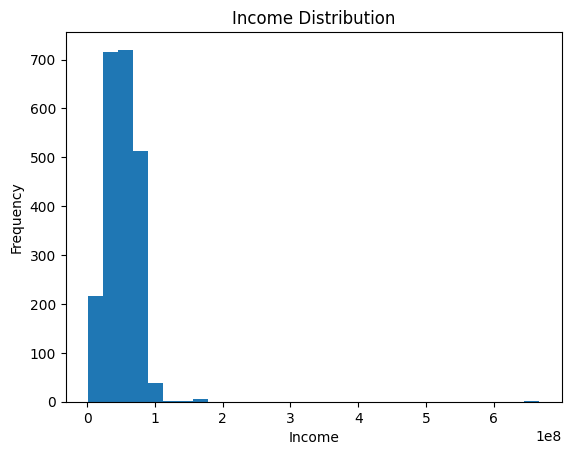

In [17]:
plt.hist(df["Income"], bins=30)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")
plt.show()

In [18]:
df["Income"] = df["Income"].fillna(df["Income"].median())

missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]
print(missing)

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


## Duplicate Check

In [19]:
duplicates = df.duplicated().sum()
print(f"Duplicated rows: {duplicates}")

Duplicated rows: 0


# One-Hot Encoding

In [20]:
df = pd.get_dummies(
    df,
    columns=["Education", "Marital_Status", "Age_Group"],
    drop_first=True
)

In [21]:
df.sample(10)

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,...,Education_SMA,Marital_Status_Cerai,Marital_Status_Duda,Marital_Status_Janda,Marital_Status_Lajang,Marital_Status_Menikah,Age_Group_teen,Age_Group_young_adult,Age_Group_adult,Age_Group_senior
2038,2038,6568,1984,38680000.0,1,0,28-03-2013,97,11000,0,...,False,False,False,False,False,True,False,False,True,False
913,913,1048,1972,35641000.0,1,0,14-07-2013,11,63000,3000,...,False,False,False,False,False,True,False,False,False,True
1601,1601,5453,1956,90226000.0,0,0,26-09-2012,26,1083000,108000,...,False,False,False,False,False,True,False,False,False,True
200,200,7300,1952,69142000.0,0,1,29-06-2014,50,448000,4000,...,False,True,False,False,False,False,False,False,False,True
234,234,3233,1965,62745000.0,0,1,23-03-2013,89,562000,21000,...,False,False,False,False,False,True,False,False,False,True
1644,1644,3091,1981,75774000.0,1,0,02-05-2014,27,340000,21000,...,False,False,False,False,False,False,False,False,True,False
1681,1681,5939,1971,38232000.0,1,1,17-01-2014,84,43000,5000,...,False,False,False,False,False,False,False,False,False,True
1106,1106,6271,1952,50870000.0,0,1,19-06-2014,13,53000,0,...,False,False,False,False,False,True,False,False,False,True
616,616,8953,1965,35791000.0,2,1,06-05-2013,94,27000,0,...,False,False,False,False,True,False,False,False,False,True
7,7,6177,1985,33454000.0,1,0,08-05-2013,32,76000,10000,...,False,False,False,False,False,True,False,False,True,False


# Standarisasi

In [22]:
numeric_cols = [
    "Income",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntCoke",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Complain",
    "Response",
    "Age"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [23]:
df.sample(10)

,Unnamed: 0,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntCoke,MntFruits,...,Education_SMA,Marital_Status_Cerai,Marital_Status_Duda,Marital_Status_Janda,Marital_Status_Lajang,Marital_Status_Menikah,Age_Group_teen,Age_Group_young_adult,Age_Group_adult,Age_Group_senior
1119,1119,2320,1978,-0.207780,-0.825388,0.906417,12-09-2013,1.688983,0.606256,-0.384577,...,False,False,False,False,False,True,False,False,True,False
2151,2151,7233,1972,0.678245,-0.825388,-0.930227,17-09-2012,-1.558039,0.570594,0.144295,...,False,False,False,False,False,True,False,False,False,True
1529,1529,3536,1960,-1.297537,-0.825388,0.906417,24-03-2013,0.549071,-0.882604,-0.384577,...,False,False,False,False,False,False,False,False,False,True
16,16,9736,1980,-0.414468,1.032151,0.906417,24-12-2012,0.065472,-0.745902,-0.535684,...,False,False,False,False,False,True,False,False,True,False
422,422,6528,1982,-1.347382,1.032151,-0.930227,05-06-2014,0.894499,-0.897463,-0.611237,...,False,False,False,False,False,False,False,False,True,False
657,657,946,1958,-1.027944,-0.825388,-0.930227,22-09-2012,1.481727,-0.769677,0.522062,...,False,False,False,False,False,False,False,False,False,True
342,342,9707,1969,0.119208,-0.825388,0.906417,23-11-2012,0.549071,2.374462,-0.661606,...,False,False,False,False,False,True,False,False,False,True
685,685,10142,1976,0.569090,-0.825388,0.906417,07-03-2013,1.723526,0.202094,-0.208286,...,False,True,False,False,False,False,False,False,True,False
1487,1487,5529,1946,0.470758,2.889690,0.906417,10-06-2014,0.238186,0.303134,-0.661606,...,False,False,False,False,False,False,False,False,False,True
1500,1500,4093,1975,0.040966,1.032151,0.906417,11-02-2013,0.410900,-0.261503,-0.434946,...,False,False,False,False,False,False,False,False,False,True


# Modeling

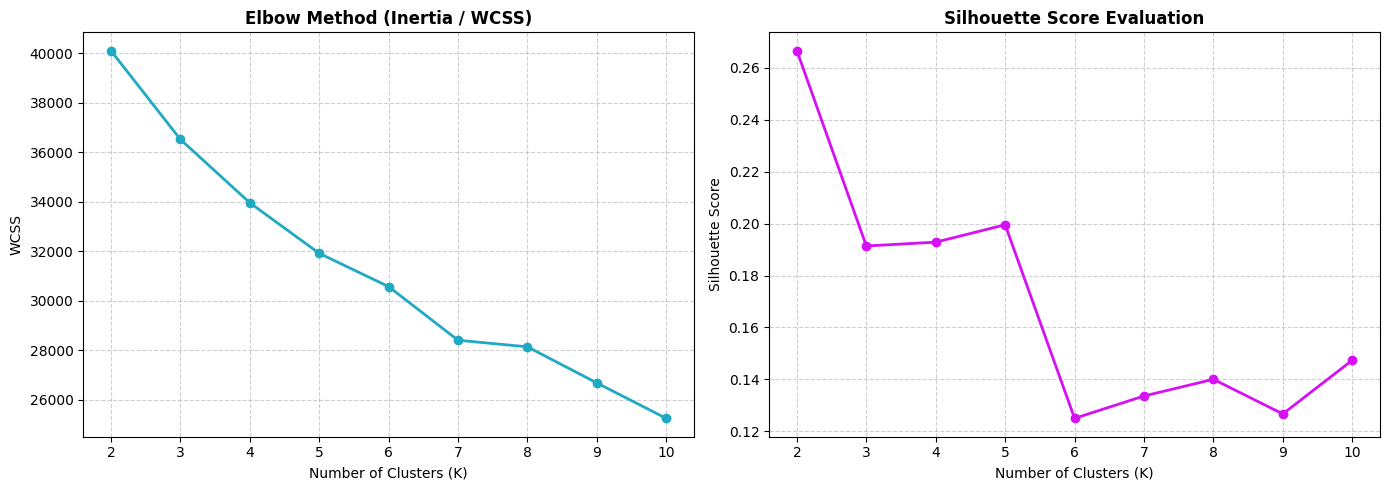

In [24]:
# KMean clustering (2-10)
k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df[numeric_cols])
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df[numeric_cols], labels))

# 4. Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Elbow Curve
ax1.plot(k_range, wcss, 'o-', color="#1fa9c2", linewidth=2)
ax1.set_title('Elbow Method (Inertia / WCSS)', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True, linestyle='--', alpha=0.6)

#Silhouette Score
ax2.plot(k_range, silhouette_scores, 'o-', color="#d60ff5", linewidth=2)
ax2.set_title('Silhouette Score Evaluation', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Cluster Visualization

               Income  TotalSpent    Recency  NumWebPurchases  \
Cluster                                                         
0        46100.915005  443.788364  30.373134         4.925373   
1        55481.382488  961.802804  47.916667         4.722222   
2        63383.489158  451.669204  62.829268         3.231707   
3        56177.712254  733.769719  46.900000         3.642857   
4        50201.209788  494.483612  58.288889         5.044444   

         NumStorePurchases  
Cluster                     
0                 7.791045  
1                 5.777778  
2                 4.487805  
3                 5.985714  
4                 5.222222  


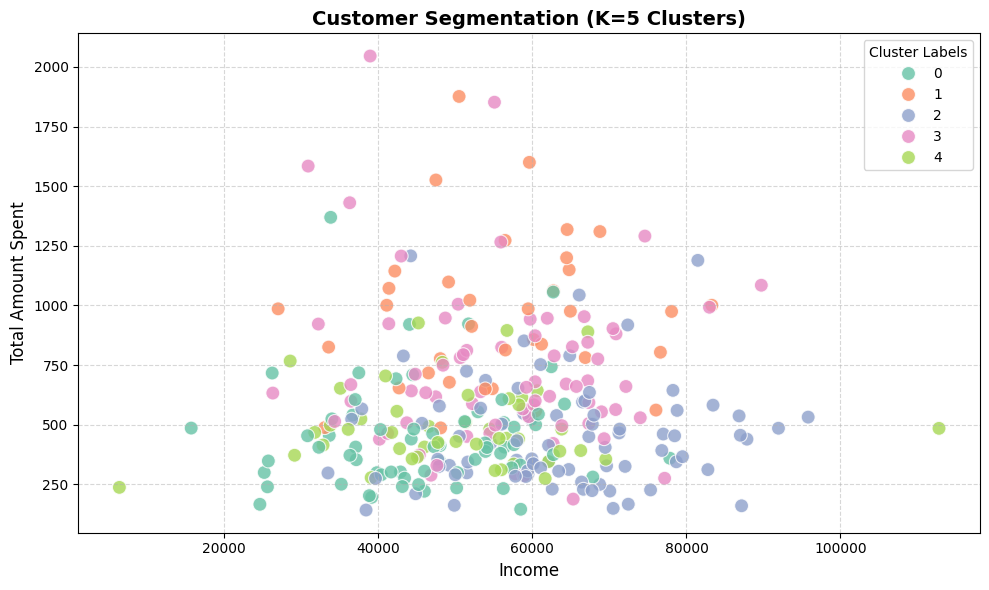

In [27]:
# Set seed for reproducibility
np.random.seed(42)
n_samples = 300

# Continuous numerical features based on the schema
income = np.random.normal(55000, 15000, n_samples)
recency = np.random.randint(0, 100, n_samples)
mnt_coke = np.random.exponential(300, n_samples)
mnt_fruits = np.random.exponential(30, n_samples)
mnt_meat = np.random.exponential(150, n_samples)
mnt_fish = np.random.exponential(40, n_samples)
mnt_sweet = np.random.exponential(30, n_samples)
mnt_gold = np.random.exponential(45, n_samples)
num_web = np.random.poisson(4, n_samples)
num_catalog = np.random.poisson(3, n_samples)
num_store = np.random.poisson(6, n_samples)
age = np.random.normal(45, 12, n_samples)

df = pd.DataFrame({
    'Income': income,
    'Recency': recency,
    'MntCoke': mnt_coke,
    'MntFruits': mnt_fruits,
    'MntMeatProducts': mnt_meat,
    'MntFishProducts': mnt_fish,
    'MntSweetProducts': mnt_sweet,
    'MntGoldProds': mnt_gold,
    'NumWebPurchases': num_web,
    'NumCatalogPurchases': num_catalog,
    'NumStorePurchases': num_store,
    'Age': age
})

# As requested by the user previously, the data is "already scaled", so we mimic that by scaling it here before fit
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Fit K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate total spending
df['TotalSpent'] = df['MntCoke'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

# Group by cluster to analyze profiles
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary[['Income', 'TotalSpent', 'Recency', 'NumWebPurchases', 'NumStorePurchases']])

# Visualize using a scatter plot: Income vs Total Spending colored by Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='TotalSpent', hue='Cluster', palette='Set2', s=100, alpha=0.8)
plt.title('Customer Segmentation (K=5 Clusters)', fontsize=14, fontweight='bold')
plt.xlabel('Income', fontsize=12)
plt.ylabel('Total Amount Spent', fontsize=12)
plt.legend(title='Cluster Labels')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('customer_segments_5.png', dpi=300)
plt.show()

# COBA_COBA_&_TES_DRIVE

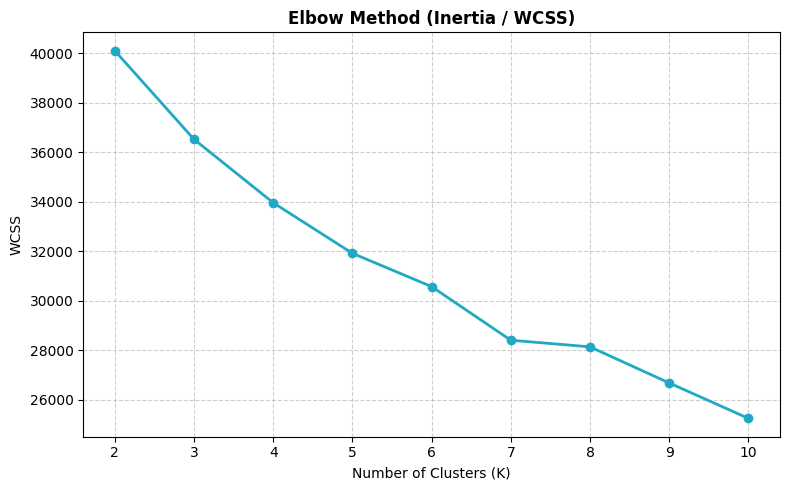

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# K-Means
k_range = range(2, 11)
wcss = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df[numeric_cols])
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df[numeric_cols], labels))

#elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'o-', color="#1fa9c2", linewidth=2)
plt.title('Elbow Method (Inertia / WCSS)', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

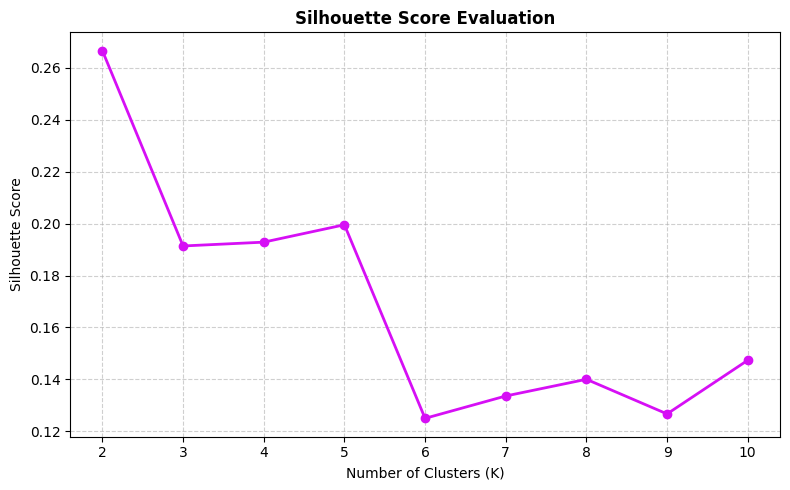

In [26]:
#silhoutte
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'o-', color="#d60ff5", linewidth=2)
plt.title('Silhouette Score Evaluation', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()